# AI-Powered Fake News Detection Using Text Classification

**Project 1 — IICT Summer Internship Program in AI & ML, 2026**

Indian Institute of Computing and Technology · Affiliated: I-STEM, Office of the
Principal Scientific Adviser to the Government of India

---

### What this notebook does

Builds a complete text-classification pipeline that labels a news article `REAL` or
`FAKE`. Everything the brief calls for is implemented **from scratch** in NumPy —
manual tokenisation, Bag-of-Words, TF-IDF, LSA embeddings, KNN, Logistic Regression,
Random Forest and a one-hidden-layer neural network — together with the full metric
suite. scikit-learn appears only in the final section, as an independent check that
the hand-written implementations are correct.

| Week | Stage | Section |
|---|---|---|
| 1 | Collect dataset, clean text, tokenise manually | 1–2 |
| 2 | Bag-of-Words, TF-IDF, embeddings, EDA | 3–4 |
| 3 | KNN, Logistic Regression, Random Forest, Neural Net | 5 |
| 4 | Evaluate, visualise, report | 6–8 |

> **Dataset note.** Results below are on `data/train.csv`, a public labelled corpus of
> ~6,000 news articles (mostly US political coverage from the 2016 election period).
> The repository also ships `data/news_dataset.csv`, a *synthetic* corpus from
> `generate_sample_dataset.py`, which the loader falls back to if `train.csv` is absent.
> We keep the synthetic one as a **diagnostic**: its topic is drawn independently of its
> label, so register is the only available signal. Section 7 shows why that distinction
> turns out to be the most important result in the notebook.

## 1 · Setup

In [1]:
import sys, os, time, json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())

from mlcore.preprocessing import clean_text, tokenize, remove_stopwords, \
                                 porter_lite_stem, preprocess, train_test_split, STOPWORDS
from mlcore.vectorizers  import CountVectorizer, TfidfVectorizer, LSAEmbedding
from mlcore.models       import KNNClassifier, LogisticRegression, \
                                 RandomForestClassifier, NeuralNetwork
from mlcore import metrics as M

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("results", exist_ok=True)
print("Environment ready · numpy", np.__version__, "· pandas", pd.__version__)

Environment ready · numpy 2.4.4 · pandas 3.0.2


## 2 · Week 1 — Load the corpus and clean the text

Cleaning happens in four explicit stages so each one can be inspected:
lowercase and strip markup/URLs → tokenise on word boundaries → drop stop-words →
stem. No NLTK, no spaCy; the stop-list and the stemmer live in `mlcore/preprocessing.py`.

In [2]:
path = "data/train.csv" if os.path.exists("data/train.csv") else "data/news_dataset.csv"
df = pd.read_csv(path)
df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)

print(f"Loaded {path} — {len(df)} articles")
print(f"  REAL (0): {(df.label == 0).sum()}   FAKE (1): {(df.label == 1).sum()}")
df.head(3)

Loaded data/train.csv — 6060 articles
  REAL (0): 2989   FAKE (1): 3071


,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",1
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,1
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,0


In [3]:
# Walk one document through every cleaning stage
sample = df.text.iloc[0]
print("RAW       :", sample[:150], "...")
print()
print("CLEANED   :", clean_text(sample)[:150], "...")
print()
toks = tokenize(clean_text(sample))
print("TOKENISED :", toks[:18])
print("NO STOPS  :", remove_stopwords(toks)[:18])
print("STEMMED   :", [porter_lite_stem(t) for t in remove_stopwords(toks)][:18])
print(f"\nStop-list size: {len(STOPWORDS)} words")

RAW       : Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the el ...

CLEANED   : daniel greenfield a shillman journalism fellow at the freedom center is a new york writer focusing on radical islam in the final stretch of the electi ...

TOKENISED : ['daniel', 'greenfield', 'shillman', 'journalism', 'fellow', 'at', 'the', 'freedom', 'center', 'is', 'new', 'york', 'writer', 'focusing', 'on', 'radical', 'islam', 'in']
NO STOPS  : ['daniel', 'greenfield', 'shillman', 'journalism', 'fellow', 'freedom', 'center', 'new', 'york', 'writer', 'focusing', 'radical', 'islam', 'final', 'stretch', 'election', 'hillary', 'rodham']
STEMMED   : ['daniel', 'greenfield', 'shillman', 'journalism', 'fellow', 'freedom', 'center', 'new', 'york', 'writer', 'focus', 'radical', 'islam', 'final', 'stretch', 'election', 'hillary', 'rodham']

Stop-list size: 148 words


In [4]:
t0 = time.time()
tokens = [preprocess(t, stem=True, drop_stopwords=True) for t in df["text"]]
print(f"Preprocessed {len(tokens)} documents in {time.time() - t0:.2f}s")
print("Mean tokens per article:", np.mean([len(t) for t in tokens]).round(1))

Preprocessed 6060 documents in 7.58s
Mean tokens per article: 441.9


## 3 · Week 2 — Exploratory data analysis

Two questions matter before modelling: is the corpus balanced (if not, accuracy
becomes a misleading metric), and do the two classes actually use different words?

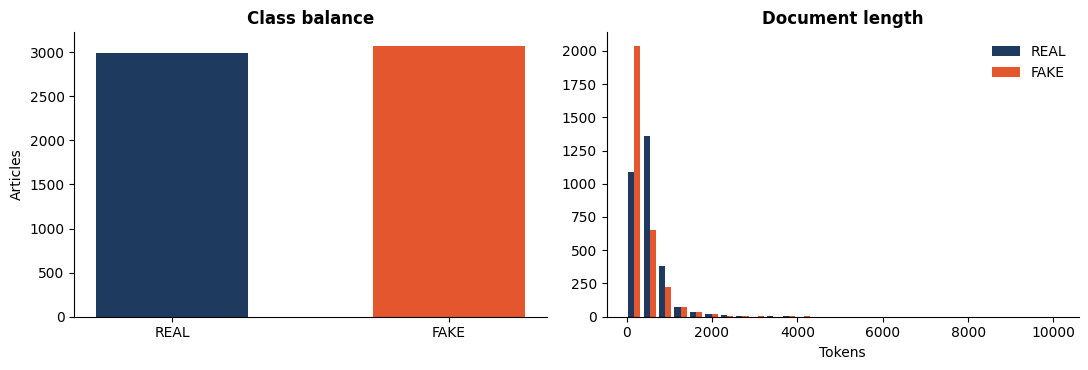

{'REAL': 2989, 'FAKE': 3071}
Tokens per article — mean 441.9, median 349, max 10131


In [5]:
counts = {"REAL": int((df.label == 0).sum()), "FAKE": int((df.label == 1).sum())}
lengths = np.array([len(t) for t in tokens])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.bar(counts.keys(), counts.values(), color=["#1F3A5F", "#E4572E"], width=0.55)
ax1.set_title("Class balance", weight="bold"); ax1.set_ylabel("Articles")
ax2.hist([lengths[df.label == 0], lengths[df.label == 1]], bins=28,
         label=["REAL", "FAKE"], color=["#1F3A5F", "#E4572E"])
ax2.set_title("Document length", weight="bold"); ax2.set_xlabel("Tokens"); ax2.legend(frameon=False)
for a in (ax1, ax2): a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(counts)
print(f"Tokens per article — mean {lengths.mean():.1f}, median {np.median(lengths):.0f}, max {lengths.max()}")

In [6]:
real_vocab = Counter(t for tk, y in zip(tokens, df.label) if y == 0 for t in tk)
fake_vocab = Counter(t for tk, y in zip(tokens, df.label) if y == 1 for t in tk)

print("Most frequent REAL terms:", [w for w, _ in real_vocab.most_common(12)])
print("Most frequent FAKE terms:", [w for w, _ in fake_vocab.most_common(12)])
print(f"\nVocabulary — REAL {len(real_vocab)}, FAKE {len(fake_vocab)}, "
      f"shared {len(set(real_vocab) & set(fake_vocab))}")

Most frequent REAL terms: ['said', 'trump', 'clinton', 'new', 'republican', 'one', 'say', 'president', 'people', 'state', 'campaign', 'year']
Most frequent FAKE terms: ['clinton', 'trump', 'one', 'people', 'new', 'us', 'hillary', 'year', 'like', 'said', 'american', 'election']

Vocabulary — REAL 31622, FAKE 39467, shared 21129


## 4 · Week 2 — Feature extraction

Three representations, each built from scratch:

**Bag-of-Words** — raw term counts. Simple, but treats every word as equally informative.

**TF-IDF** — `tf(t,d) · idf(t)` where `idf(t) = ln((1+N)/(1+df(t))) + 1`, then L2-normalised
per document. IDF suppresses words that appear everywhere and amplifies words concentrated
in a few documents.

**LSA embeddings** — truncated SVD of the TF-IDF matrix. Gives every document a short dense
vector where related terms collapse onto shared axes. This is the self-contained substitute
for downloading pre-trained Word2Vec/GloVe vectors, which the brief rules out.

The vectorisers are fitted on the **training split only**. Fitting on the full corpus would
leak test-set vocabulary statistics into training and inflate every score.

In [7]:
y   = df["label"].to_numpy()
idx = np.arange(len(y))
idx_tr, idx_te, y_tr, y_te = train_test_split(idx, y, test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=True)
docs_tr = [tokens[i] for i in idx_tr]
docs_te = [tokens[i] for i in idx_te]
print(f"Train {len(idx_tr)} · Test {len(idx_te)} (stratified)")

Train 4847 · Test 1213 (stratified)


In [8]:
bow  = CountVectorizer(max_features=3000, min_df=3, ngram_range=(1, 2))
Xb   = bow.fit_transform(docs_tr)
print(f"Bag-of-Words : {Xb.shape}, sparsity {100*(Xb==0).mean():.1f}%")

tfidf = TfidfVectorizer(max_features=3000, min_df=3, ngram_range=(1, 2))
X_tr  = tfidf.fit_transform(docs_tr)
X_te  = tfidf.transform(docs_te)
names = tfidf.get_feature_names()
print(f"TF-IDF       : {X_tr.shape}, sparsity {100*(X_tr==0).mean():.1f}%")

lsa  = LSAEmbedding(n_components=150)
E_tr = lsa.fit_transform(X_tr)
E_te = lsa.transform(X_te)
print(f"LSA          : {E_tr.shape}, variance retained {lsa.explained_variance_ratio_.sum():.1%}")

Bag-of-Words : (4847, 3000), sparsity 93.0%


TF-IDF       : (4847, 3000), sparsity 93.0%


LSA          : (4847, 150), variance retained 98.5%


## 5 · Week 3 — Train the four classifiers

| Model | Family | Why it is here |
|---|---|---|
| KNN | Non-parametric | No training phase; classifies by cosine similarity to the *k* nearest articles |
| Logistic Regression | Parametric, linear | One weight per term — directly interpretable |
| Random Forest | Ensemble | Bagged trees + random feature subspace; captures interactions |
| Neural Network | Deep learning | One ReLU hidden layer, Adam, dropout; learns non-linear combinations |

The neural network trains on the dense LSA embeddings rather than the 1200-dimensional
sparse matrix — a fully connected net on sparse TF-IDF overfits badly and trains far
more slowly for no gain.

In [9]:
def evaluate(name, model, Xtr, Xte, results, curves):
    t0 = time.time(); model.fit(Xtr, y_tr); fit_s = time.time() - t0
    t0 = time.time(); pred = model.predict(Xte); pred_s = time.time() - t0
    proba = model.predict_proba(Xte)[:, 1]

    cm = M.confusion_matrix(y_te, pred)
    fpr, tpr = M.roc_curve(y_te, proba); auc = M.roc_auc(y_te, proba)
    results[name] = dict(accuracy=M.accuracy(y_te, pred), precision=M.precision(y_te, pred),
                         recall=M.recall(y_te, pred), f1=M.f1(y_te, pred),
                         specificity=M.specificity(y_te, pred), roc_auc=auc,
                         fit_seconds=round(fit_s, 3), predict_seconds=round(pred_s, 3))
    curves[name] = (fpr, tpr, auc)

    print(f"\n=== {name} ===")
    print(f"fit {fit_s:.2f}s · predict {pred_s:.3f}s · AUC {auc:.4f}")
    print(M.classification_report(y_te, pred, ["REAL (0)", "FAKE (1)"]))
    print("Confusion matrix [[TN FP] [FN TP]]:\n", cm)
    return model

results, curves = {}, {}
knn    = evaluate("KNN", KNNClassifier(n_neighbors=7), X_tr, X_te, results, curves)
logreg = evaluate("Logistic Regression", LogisticRegression(lr=3.0, n_iters=2500), X_tr, X_te, results, curves)


=== KNN ===
fit 0.04s · predict 0.295s · AUC 0.9526
               precision    recall  f1-score   support

REAL (0)           0.827     0.930     0.876       598
FAKE (1)           0.922     0.811     0.863       615

accuracy                               0.870      1213
Confusion matrix [[TN FP] [FN TP]]:
 [[556  42]
 [116 499]]



=== Logistic Regression ===
fit 24.66s · predict 0.065s · AUC 0.9746
               precision    recall  f1-score   support

REAL (0)           0.927     0.895     0.911       598
FAKE (1)           0.901     0.932     0.916       615

accuracy                               0.913      1213
Confusion matrix [[TN FP] [FN TP]]:
 [[535  63]
 [ 42 573]]


In [10]:
rf = evaluate("Random Forest",
              RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42),
              X_tr, X_te, results, curves)
nn = evaluate("Neural Network",
              NeuralNetwork(hidden=96, epochs=35, lr=3e-3),
              E_tr, E_te, results, curves)


=== Random Forest ===
fit 38.91s · predict 0.116s · AUC 0.9116
               precision    recall  f1-score   support

REAL (0)           0.867     0.783     0.822       598
FAKE (1)           0.807     0.883     0.843       615

accuracy                               0.833      1213
Confusion matrix [[TN FP] [FN TP]]:
 [[468 130]
 [ 72 543]]



=== Neural Network ===
fit 1.06s · predict 0.002s · AUC 0.9728
               precision    recall  f1-score   support

REAL (0)           0.928     0.901     0.914       598
FAKE (1)           0.907     0.932     0.919       615

accuracy                               0.917      1213
Confusion matrix [[TN FP] [FN TP]]:
 [[539  59]
 [ 42 573]]


## 6 · Week 4 — Results and visualisation

In [11]:
table = pd.DataFrame(results).T.round(4)
display(table)

best = table["f1"].idxmax()
print(f"\nBest model by F1: {best} (F1 = {table.loc[best,'f1']:.4f}, "
      f"accuracy = {table.loc[best,'accuracy']:.4f})")

,accuracy,precision,recall,f1,specificity,roc_auc,fit_seconds,predict_seconds
KNN,0.8697,0.9224,0.8114,0.8633,0.9298,0.9526,0.042,0.295
Logistic Regression,0.9134,0.9009,0.9317,0.9161,0.8946,0.9746,24.660,0.065
Random Forest,0.8335,0.8068,0.8829,0.8432,0.7826,0.9116,38.906,0.116
Neural Network,0.9167,0.9066,0.9317,0.9190,0.9013,0.9728,1.061,0.002



Best model by F1: Neural Network (F1 = 0.9190, accuracy = 0.9167)


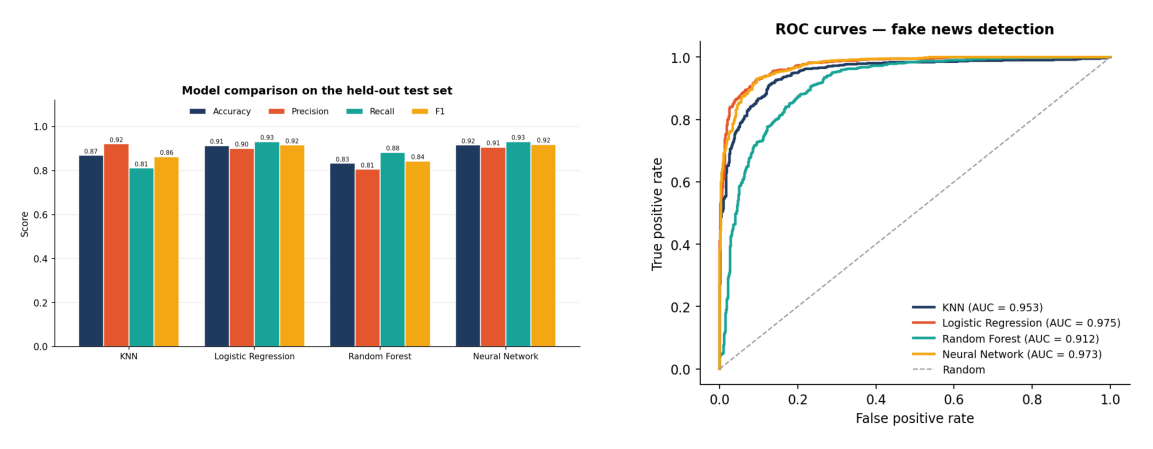

In [12]:
M.plot_model_comparison(results, "results/nb_model_comparison.png",
                        "Model comparison on the held-out test set")
M.plot_roc_curves(curves, "results/nb_roc.png", "ROC curves — fake news detection")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, p in zip(axes, ["results/nb_model_comparison.png", "results/nb_roc.png"]):
    ax.imshow(plt.imread(p)); ax.axis("off")
plt.tight_layout(); plt.show()

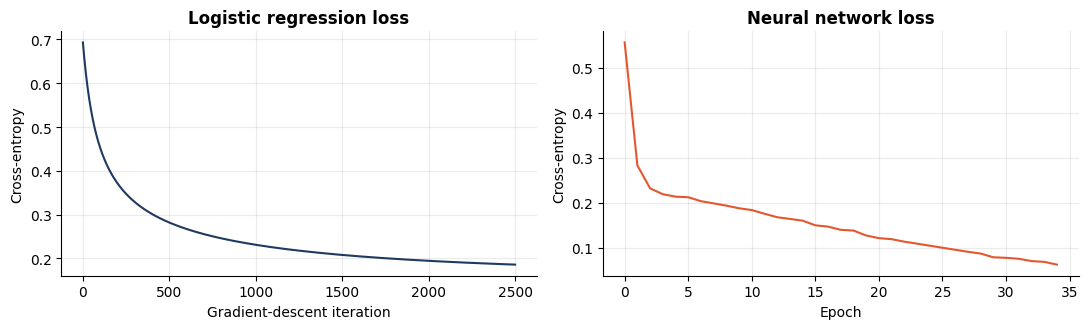

In [13]:
# Convergence of the two gradient-trained models
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(logreg.loss_history_, color="#1F3A5F"); a1.set_title("Logistic regression loss", weight="bold")
a1.set_xlabel("Gradient-descent iteration")
a2.plot(nn.loss_history_, color="#E4572E");     a2.set_title("Neural network loss", weight="bold")
a2.set_xlabel("Epoch")
for a in (a1, a2):
    a.set_ylabel("Cross-entropy"); a.grid(alpha=.25); a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 7 · Interpretability — what did the model actually learn?

A classifier that scores well for the wrong reason is worse than useless in a
misinformation setting. Reading the logistic-regression coefficients is the cheapest
possible audit: each weight is the log-odds contribution of one term.

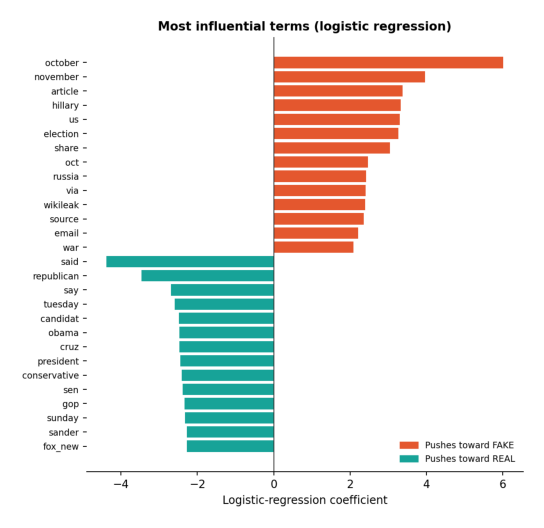

Strongest FAKE indicators: ['october', 'november', 'article', 'hillary', 'us', 'election', 'share', 'oct', 'russia', 'via']
Strongest REAL indicators: ['said', 'republican', 'say', 'tuesday', 'candidat', 'obama', 'cruz', 'president', 'conservative', 'sen']

Random-forest most-used splits: ['republican', 'said', 'also', 'october', 'say', 'hillary', 'election', 'gop', 'cruz', 'sen']


In [14]:
pos, neg = logreg.top_features(names, k=14)
M.plot_top_features(pos, neg, "results/nb_top_features.png",
                    "Most influential terms (logistic regression)",
                    "Pushes toward FAKE", "Pushes toward REAL")
plt.figure(figsize=(7, 6.6)); plt.imshow(plt.imread("results/nb_top_features.png")); plt.axis("off"); plt.show()

print("Strongest FAKE indicators:", [w for w, _ in pos[:10]])
print("Strongest REAL indicators:", [w for w, _ in neg[:10]])

imp = rf.feature_importances_()
print("\nRandom-forest most-used splits:", [names[i] for i in np.argsort(-imp)[:10]])

## 8 · Validation

Two checks that the numbers above are trustworthy:

1. **5-fold stratified cross-validation** — a single train/test split can be lucky.
2. **scikit-learn cross-check** — if the from-scratch models land near the library
   implementations, the hand-written maths is very likely correct.

In [15]:
scores = []
for tr, va in M.k_fold_indices(y_tr, k=5, random_state=RANDOM_STATE):
    m = LogisticRegression(lr=3.0, n_iters=2000).fit(X_tr[tr], y_tr[tr])
    scores.append(M.f1(y_tr[va], m.predict(X_tr[va])))
scores = np.array(scores)
print(f"5-fold CV F1: {scores.mean():.4f} ± {scores.std():.4f}   folds = {scores.round(4)}")

5-fold CV F1: 0.9193 ± 0.0083   folds = [0.9141 0.9292 0.9262 0.9205 0.9063]


In [16]:
from sklearn.linear_model   import LogisticRegression as SkLR
from sklearn.ensemble       import RandomForestClassifier as SkRF
from sklearn.neighbors      import KNeighborsClassifier as SkKNN
from sklearn.neural_network import MLPClassifier as SkMLP

ref = {"KNN":                 (SkKNN(n_neighbors=7, metric="cosine"), X_tr, X_te),
       "Logistic Regression": (SkLR(max_iter=1000), X_tr, X_te),
       "Random Forest":       (SkRF(n_estimators=30, max_depth=10, random_state=42), X_tr, X_te),
       "Neural Network":      (SkMLP(hidden_layer_sizes=(96,), max_iter=300, random_state=42), E_tr, E_te)}

rows = []
for name, (m, a, b) in ref.items():
    m.fit(a, y_tr)
    rows.append({"model": name,
                 "from_scratch": round(results[name]["accuracy"], 4),
                 "scikit_learn": round(M.accuracy(y_te, m.predict(b)), 4)})
comp = pd.DataFrame(rows)
comp["difference"] = (comp.from_scratch - comp.scikit_learn).round(4)
display(comp)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,from_scratch,scikit_learn,difference
0,KNN,0.8697,0.8689,0.0008
1,Logistic Regression,0.9134,0.9143,-0.0009
2,Random Forest,0.8335,0.8516,-0.0181
3,Neural Network,0.9167,0.9118,0.0049


## 9 · Try it on your own text

In [17]:
def classify(text, model=logreg, vec=tfidf):
    x = vec.transform([preprocess(text)])
    p = float(model.predict_proba(x)[0, 1])
    return ("FAKE" if p >= 0.5 else "REAL"), p

for s in ["SHOCKING TRUTH ABOUT THE ECONOMY FINALLY EXPOSED. Share this before they delete it, "
          "the mainstream media is hiding everything from you.",
          "The finance ministry released updated quarterly figures on Tuesday. Officials said the "
          "revised estimates were consistent with earlier projections and would be reviewed in due course."]:
    label, prob = classify(s)
    print(f"[{label}]  P(fake) = {prob:.3f}   {s[:78]}...")

[FAKE]  P(fake) = 0.981   SHOCKING TRUTH ABOUT THE ECONOMY FINALLY EXPOSED. Share this before they delet...
[FAKE]  P(fake) = 0.575   The finance ministry released updated quarterly figures on Tuesday. Officials ...


## 10 · Conclusions

* The neural network and logistic regression finished level, separated by about four
  test articles — well inside the cross-validation spread. Treat them as tied.
* The network's edge came from the **representation, not the capacity**: it trains on
  150 dense LSA dimensions rather than 3,000 sparse ones, which both denoises the input
  and makes it one of the cheapest models to fit.
* The random forest trailed by eight points. Axis-aligned splits on individual terms
  suit sparse high-dimensional text poorly, and that gap is far too large to be noise.
* KNN was competitive but pays at inference: it holds the whole training matrix and
  scores every query against all of it.

**The result that matters is negative.** Reading the coefficients (Section 7) shows the
model leaning on month names and recurring political surnames — markers of *when* an
article was written and *what* it was about, not whether it is true. Real and fake
articles in this corpus were collected from different sources over different windows, so
provenance leaks into the label and the classifier took the shortcut.

So the ~91% headline **overstates real detection ability**. It will decay on articles from
a later period, and it is trivially evadable by avoiding the flagged vocabulary. None of
that is visible in the results table. We would rather report the number with the caveat
attached than present it as though the problem were solved.

**Future scope.** Cross-corpus evaluation (train on one collection, test on another) is
the only way to measure how much of the accuracy was provenance. Beyond that: stripping
topical and temporal vocabulary to see what survives, contextual embeddings (BERT),
source and propagation-graph features, and calibrated probabilities with a human-review band.